## Lab 3: Importing and Deploying the Model to Bedrock for Inference

**⏱️ Estimated completion time: 5 minutes**

### Lab overview

Brief: This lab demonstrates how to import a fine-tuned Nova-Lite model from SageMaker into Amazon Bedrock and deploy it for on-demand inference. You'll learn the complete workflow from model import to deployment, understanding the differences between provisioned throughput and on-demand inference options.

Expected outputs: A deployed custom model in Bedrock ready for inference, with deployment ARN stored for use in subsequent notebooks.

**Key Learning Objectives:**
- Understand Bedrock's custom model import process
- Learn about deployment options (Provisioned Throughput vs On-Demand)
- Experience the complete MLOps workflow from training to production deployment
- Explore Bedrock's model management capabilities

**Workshop Progress:**
- ✅ Lab 1: Data Preparation
- ✅ Lab 2: Fine-tuning Nova-Lite   
- ⏳ Lab 3: Import & Deploy to Bedrock (5 mins) ← 📍 You are here
- ⏳ Lab 4: Inference & Qualitative Testing (10 mins)
- ⏳ Lab 5: Quantitative Evaluation (5 mins)

### 🎯 Workshop Context

In this lab, you'll import the custom model artifacts from the escrow S3 bucket and deploy it on  Bedrock. Trained model artifacts and checkpoints are stored in your designated escrow S3 bucket. You can access the training checkpoint location from the `describe_training_job` response.

By calling `create_custom_model` API, you can create your custom model referencing the model artifacts stored in your S3 escrow bucket. This process bridges the gap between SageMaker training and Bedrock inference, enabling you to leverage Bedrock's managed inference capabilities for your custom models.

**Why import and deploy on Bedrock?**
- Simplified inference management
- Built-in scaling and load balancing
- Integration with AWS services
- Cost-effective on-demand pricing for LoRA models

### Prerequisites
- You have already run Labs 1 and 2.

### 1 — Environment setup and AWS service initialization

Brief: Import required libraries and initialize AWS service clients. This establishes connections to SageMaker (for retrieving training artifacts) and Bedrock (for model import and deployment).

Why we're doing this: We need both SageMaker and Bedrock clients to complete the model import workflow. The SageMaker session helps us access training outputs, while Bedrock client manages custom model operations.

What to check after running: Verify no import errors and that all required libraries are available.

References: 
- [Bedrock Custom Models Documentation](https://docs.aws.amazon.com/bedrock/latest/userguide/custom-models.html)
- [SageMaker Python SDK](https://sagemaker.readthedocs.io/)

⚠️ Note: 

Please select the following **Python Environment** to run this notebook.

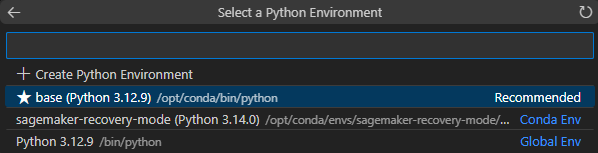

In [ ]:
# Core libraries for AWS service interaction and data handling
import os
import json
import boto3
import sagemaker
from sagemaker import get_execution_role

# Additional library for monitoring deployment status
import time

### 2 — Configure AWS session and execution role

Brief: Set up AWS session context and retrieve the execution role that will be used for Bedrock operations. The execution role must have permissions for both SageMaker and Bedrock services.

Why we're doing this: Bedrock's `create_custom_model` API requires an IAM role with specific permissions to access S3 model artifacts and manage Bedrock resources. This role acts as the service principal for Bedrock operations.

**🔍 Exploration Task**: Navigate to the IAM console and examine the permissions attached to this execution role. What specific policies enable Bedrock operations?

In [ ]:
region_name = boto3.Session().region_name
sm_client = boto3.client("sagemaker", region_name=region_name)
sagemaker_session = sagemaker.session.Session(
    boto_session=boto3.session.Session(), sagemaker_client=sm_client
)
role_arn = get_execution_role()
role_arn

Lets retreive the S3 URIs from the previous notebooks.

In [ ]:
# Retrieve the vars we stored
%store -r train_dataset_s3_path val_dataset_s3_path test_dataset_s3_path output tensorboard escrow_model_uri
train_dataset_s3_path, val_dataset_s3_path, test_dataset_s3_path, output, tensorboard, escrow_model_uri

## 3. Create a custom model import job 

We are going to use the Bedrock Boto3 client to create a custom model import job. 

By calling `create_custom_model` API, you can create your custom model referencing the model artifacts stored in your S3 escrow bucket.

In [ ]:
bedrock_client = boto3.Session().client(service_name="bedrock", region_name=region_name)

s3_checkpoint_path = escrow_model_uri

custom_model_name = "my-nova-ft-docvqa"  # give it the name you want

try:
    custom_model_response = bedrock_client.create_custom_model(
        modelName=custom_model_name,
        modelSourceConfig={"s3DataSource": {"s3Uri": s3_checkpoint_path}},
        roleArn=role_arn,
        # Optionally, add modelTags here
    )
    print("Custom model ARN:", custom_model_response["modelArn"])
except Exception as e:
    print(f"An unexpected error occurred: {e}")

The custom model imported to Bedrock has an ARN, which can be used to deploy the model on Bedrock as real-time endpoint. 

In [ ]:
custom_model_arn = custom_model_response["modelArn"]
custom_model_arn

## 3. Monitoring Custom model import to Bedrock

The custom model import job could take upto 40 minutes to complete. To monitor the job, use the `get_custom_model` operation to retrieve the job status.


In [ ]:
import time
while True:
    response = bedrock_client.get_custom_model(modelIdentifier=custom_model_name)
    model_status = response["modelStatus"]
    print(f"Custom model status: {model_status}")
    if model_status == "Active":
        break
    elif model_status in ["Failed"]:
        raise Exception(f"Custom model creation failed with status: {model_status}")
    time.sleep(30)
print("Custom model is ACTIVE.")
response

At the end of the custom model import you will see `Custom model is ACTIVE`. 

You can also see its ARN and other details as shown below:

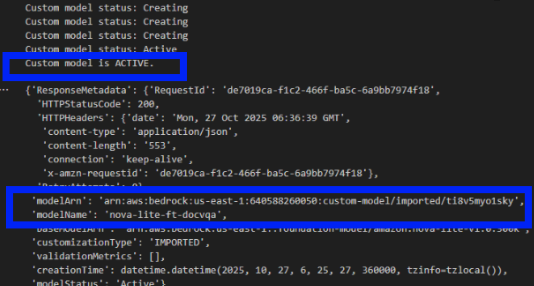

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li>Stop the custom model import job that we just started in Step 3.</li>
</ul>



***1. Click on the Stop icon at Step3 as shown below.***

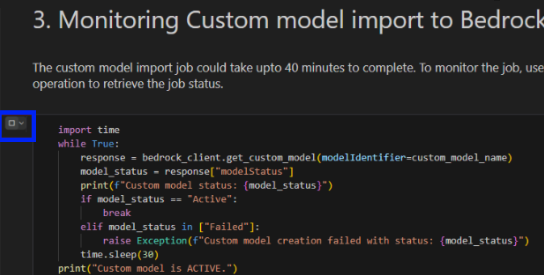

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li> Copy the ARN of the prerun custom model import job and paste it in the next cell. </li>
</ul>


***1. Navigate to Amazon Bedrock console.***

***2. Click on  `Custom models` tab on the left panel.***

***3. Click on the prerun import job that starts with `nova-custom-prerun-`.***

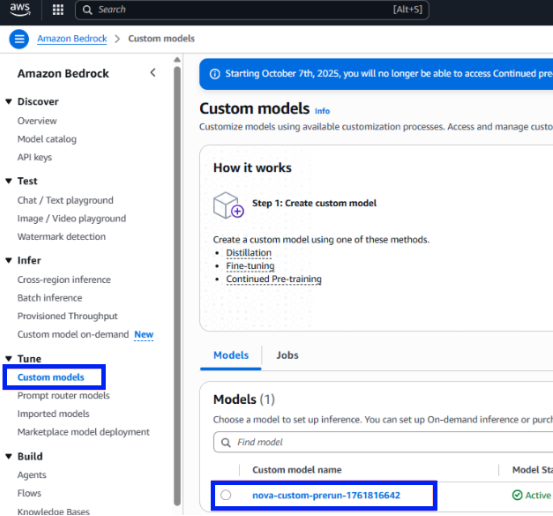

***4. Copy the ARN of the prerun imported model and paste in the below cell.***

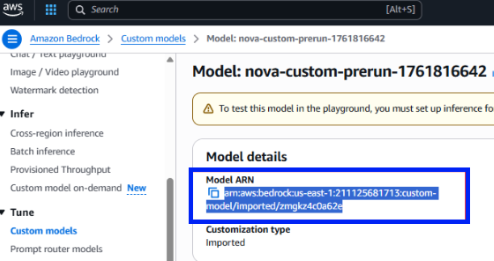


In [ ]:
# Paste your custom model ARN below"
custom_model_arn = "Paste here"
custom_model_arn

## 4. Deploy custom model for Inference on Bedrock

After you create a custom model, you can set up inference using one of the following options:
1. **Purchase Provisioned Throughput** – Purchase Provisioned Throughput for your model to set up dedicated compute capacity with guaranteed throughput for consistent performance and lower latency.
For more information about Provisioned Throughput, see [Increase model invocation capacity with Provisioned Throughput in Amazon Bedrock](https://docs.aws.amazon.com/bedrock/latest/userguide/prov-throughput.html). For more information about using custom models with Provisioned Throughput, [see Purchase Provisioned Throughput for a custom model](https://docs.aws.amazon.com/bedrock/latest/userguide/custom-model-use-pt.html).
2. **Deploy custom model for on-demand inference (only LoRA fine-tuned Amazon Nova models)** – To set up on-demand inference, you deploy the custom model with a custom model deployment. After you deploy the model, you invoke it using the ARN for the custom model deployment. With on-demand inference, you only pay for what you use and you don't need to set up provisioned compute resources.
For more information about deploying custom models for on-demand inference, see [Deploy a custom model for on-demand inference](https://docs.aws.amazon.com/bedrock/latest/userguide/deploy-custom-model-on-demand.html).


**In this lab we'll go with Option 2 : On-Demand Inference**

### Deploy custom model for On-Demand Inference
**Important Note:** On-demand inference is currently supported only for LoRA-based fine-tuned models.

We are going to deploy the imported model for on-demand inference using Bedrock boto3 client `create_custom_model_deployment` API.

In [ ]:
model_deployment_name = "nova-lite-ft-docvqa-endpoint"

try:
    response = bedrock_client.create_custom_model_deployment(
        modelDeploymentName=model_deployment_name,
        modelArn=custom_model_arn,
        description="Nova Lite PEFT-Lora on DocVqa dataset",        
    )
    custom_model_deployment_arn = response["customModelDeploymentArn"]
    print("Custom model deployment ARN:", custom_model_deployment_arn)
except Exception as e:
    print(f"An unexpected error occurred: {e}")
response

Custom model deployement could take 2-3mins. Monitor the status using `get_custom_model_deployment` API. 

In [ ]:
while True:
    response = bedrock_client.get_custom_model_deployment(customModelDeploymentIdentifier=custom_model_deployment_arn)
    model_status = response["status"]
    print(f"Custom model deployment status: {model_status}")
    if model_status == "Active":
        break
    elif model_status in ["Failed"]:
        raise Exception(f"Custom model deployment failed with status: {model_status}")
    time.sleep(30)
print("Custom model is ACTIVE.")
response

Below is the ARN of the custom model deployed.

In [ ]:
custom_model_deployment_arn = response['customModelDeploymentArn']
custom_model_deployment_arn

We'll save this ARN for the next notebook where we will send inference requests to this endpont and compare its response with that of other Bedrock models in the Test app!

In [ ]:
%store custom_model_deployment_arn

You can also see that the custom model is deployed in the Bedrock console.

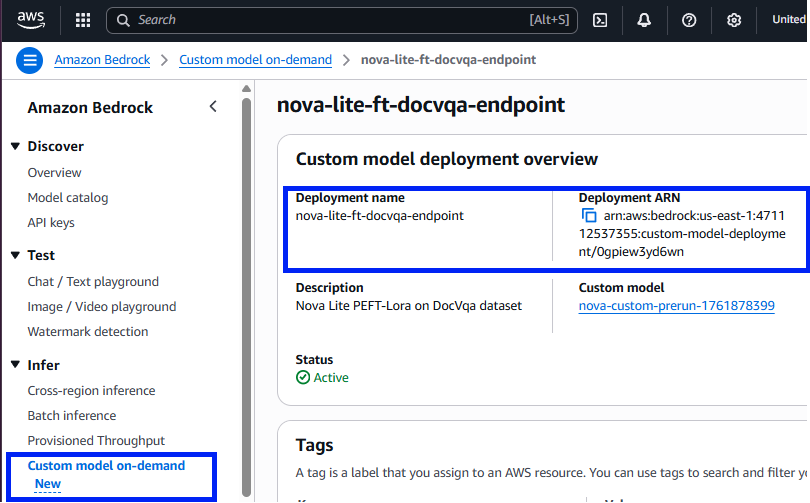

## 🎉 Lab 3 Complete!

**Congratulations!** You have successfully completed the model import and deployment to Bedrock phase. Here's what you accomplished:

### ✅ Tasks Completed:
1. **Environment Setup** - Initialized AWS service clients and session configuration
2. **Model Import** - Created custom model import job in Bedrock 
3. **Import Monitoring** - Tracked custom model import status until completion
4. **Deployment Setup** - Prepared model for inference through Bedrock
5. **Status Tracking** - Monitored model deployment progress
6. **Documentation** - Stored model ARNs and configurations

### 📁 Key Outputs:
- **Custom Model**: Successfully imported model in Bedrock
- **Model ARN**: Unique identifier for deployed model
- **Import Status**: Completed model import verification
- **Deployment Config**: Model serving configuration
- **Access Controls**: Configured IAM permissions

### 🚀 Next Step:
- **Inference Testing**: Validate model performance

### **Ready for testing? Proceed to Lab 4!**

